# Import Library

In [1]:
import os
import random
import shutil

import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report

# Setup Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Dicoding/3. Belajar Pengembangan Machine Learning'

!mkdir -p ~/.kaggle
!cp '{path}/kaggle.json' ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d orvile/brain-cancer-mri-dataset

!unzip -o '/content/brain-cancer-mri-dataset.zip' -d '/content'

Streaming output truncated to the last 5000 lines.
  inflating: /content/Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1058.jpg  
  inflating: /content/Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1059.jpg  
  inflating: /content/Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1060.jpg  
  inflating: /content/Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1061.jpg  
  inflating: /content/Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1062.jpg  
  inflating: /content/Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1063.jpg  
  inflating: /content/Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1064.jpg  
  inflating: /content/Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1065.jpg  
  inflating: /content/Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1066.jpg  
  inflating: /content/Brain_Cancer raw MRI data/Brain_Cancer/brain_

In [3]:
shutil.move("/content/Brain_Cancer raw MRI data/Brain_Cancer", "/content/Brain_Cancer")

shutil.rmtree("/content/Brain_Cancer raw MRI data")

In [4]:
base_path = "/content/Brain_Cancer"

for folder_name in os.listdir(base_path):
    old_path = os.path.join(base_path, folder_name)
    if os.path.isdir(old_path) and folder_name.startswith("brain_"):
        new_name = folder_name.replace("brain_", "")
        new_path = os.path.join(base_path, new_name)
        os.rename(old_path, new_path)

# mini EDA

Jumlah gambar per label:
tumor: 2048
glioma: 2004
menin: 2004


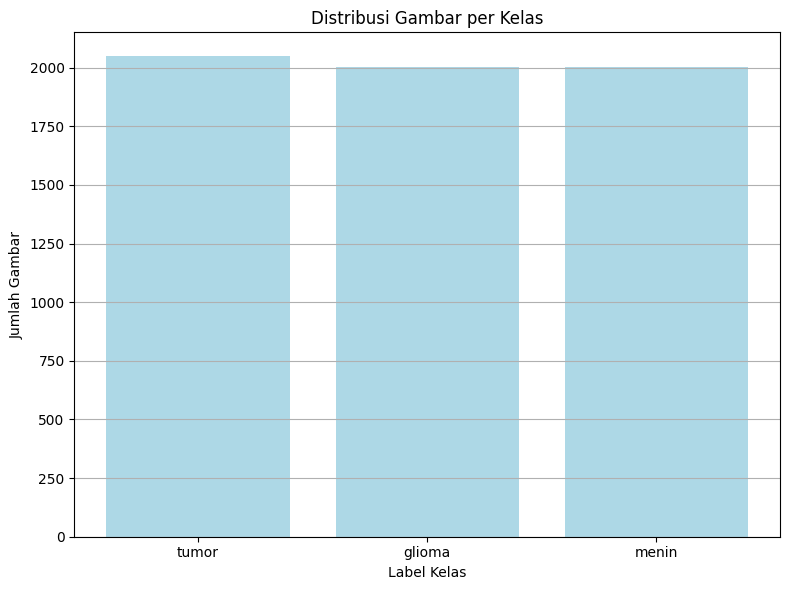

In [5]:
label_counts = {}
for label in os.listdir(base_path):
    label_dir = os.path.join(base_path, label)
    if os.path.isdir(label_dir):
        count = len([f for f in os.listdir(label_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
        label_counts[label] = count

print("Jumlah gambar per label:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(8, 6))
plt.bar(labels, counts, color='lightblue')
plt.title("Distribusi Gambar per Kelas")
plt.xlabel("Label Kelas")
plt.ylabel("Jumlah Gambar")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

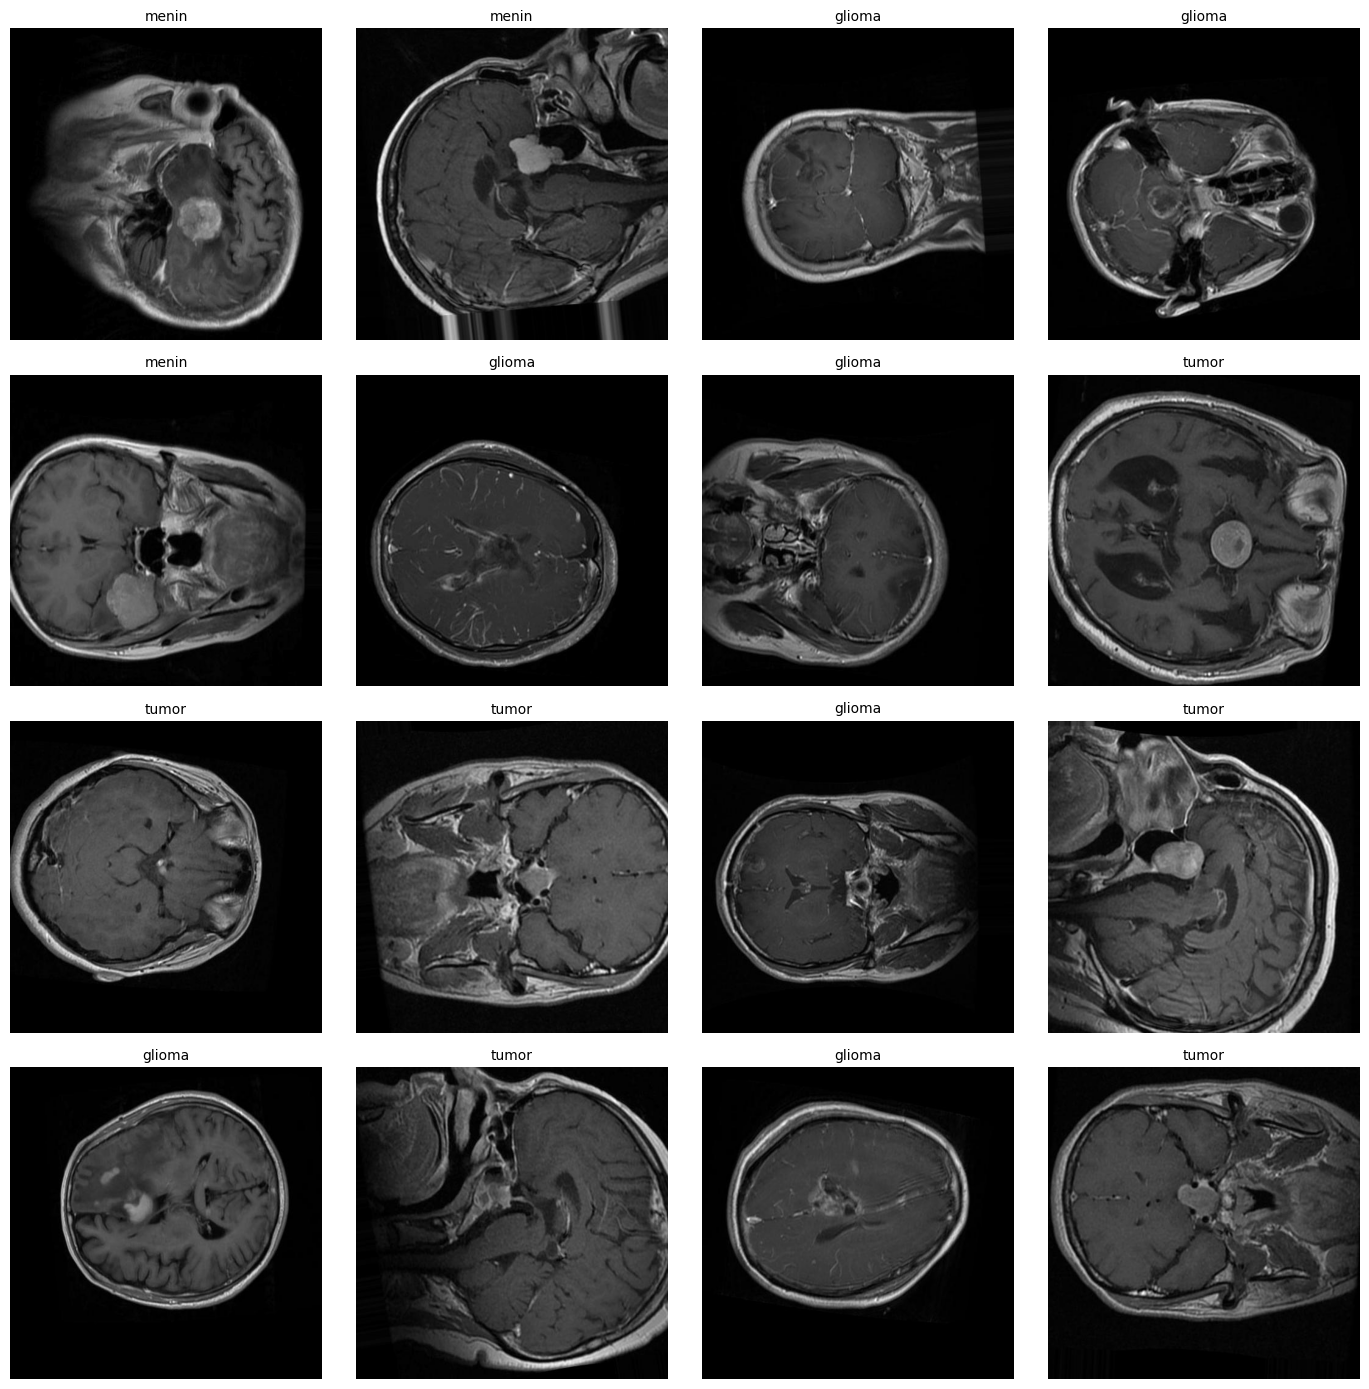

In [6]:
samples = random.sample(
    [(os.path.join(base_path, label, f), label) for label in os.listdir(base_path)
     for f in os.listdir(os.path.join(base_path, label))], 16)

plt.figure(figsize=(14, 14))
for i, (path, label) in enumerate(samples):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(label, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Preprocessing

In [7]:
img_size = (224, 224)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

Found 6056 files belonging to 3 classes.
Using 4845 files for training.
Found 6056 files belonging to 3 classes.
Using 1211 files for validation.


In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Modeling

In [9]:
num_classes = 3

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,643 (9.92 MB)

 Trainable params: 2,600,643 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

# Training

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    verbose=1
)

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 32s 96ms/step - accuracy: 0.5553 - loss: 0.9162 - val_accuracy: 0.6899 - val_loss: 0.6590
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.7090 - loss: 0.6624 - val_accuracy: 0.7761 - val_loss: 0.5462
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7629 - loss: 0.5961 - val_accuracy: 0.8027 - val_loss: 0.4820
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.7918 - loss: 0.5156 - val_accuracy: 0.7944 - val_loss: 0.5013
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7983 - loss: 0.4741 - val_accuracy: 0.8259 - val_loss: 0.4334
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8324 - loss: 0.4128 - val_accuracy: 0.7993 - val_loss: 0.5299
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.8398 - loss: 0.3982 - val_accuracy: 0.8408 - val_loss: 0.4143
Epoch 8/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.8737 - loss: 0.3260 - val

# Evaluation

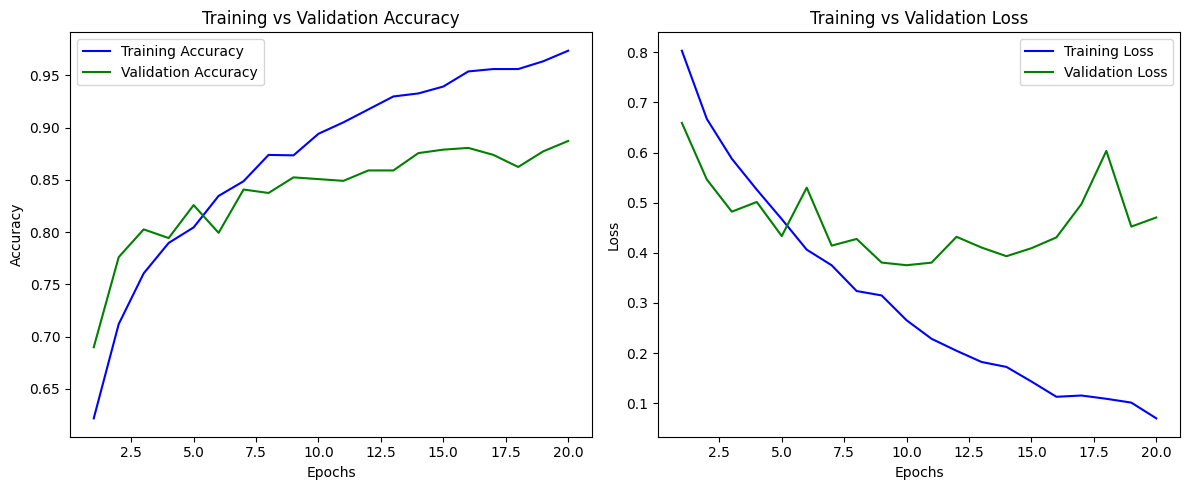

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'g-', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'g-', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Brain_Cancer",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical"
)

class_names = raw_train_ds.class_names

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

Found 6056 files belonging to 3 classes.
Using 4845 files for training.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 840ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [13]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      glioma       0.92      0.83      0.87       198
       menin       0.82      0.83      0.82       207
       tumor       0.87      0.94      0.90       203

    accuracy                           0.87       608
   macro avg       0.87      0.87      0.87       608
weighted avg       0.87      0.87      0.87       608



# Save Model

In [14]:
save_dir = "/content/images-classification"

saved_model_path = os.path.join(save_dir, "saved_model")
tflite_path = os.path.join(save_dir, "tflite")
tfjs_path = os.path.join(save_dir, "tfjs_model")

In [15]:
os.makedirs(saved_model_path, exist_ok=True)
os.makedirs(tflite_path, exist_ok=True)
os.makedirs(tfjs_path, exist_ok=True)

## SavedModel

In [16]:
model.export(saved_model_path)

Saved artifact at '/content/images-classification/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134499617125968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134499617127504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134499617127120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134499617126928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134499617126160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134499599009360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134499599009936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134499599010320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134499599010704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134499599012240: TensorSpec(shape=(), dtype=tf.resource, n

## TensorFlow Lite

In [17]:
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

with open(os.path.join(tflite_path, "model.tflite"), "wb") as f:
    f.write(tflite_model)

# (Opsional) Simpan label.txt
with open(os.path.join(tflite_path, "label.txt"), "w") as f:
    for class_name in class_names:
        f.write(f"{class_name}\n")

## TensorFlow.js

In [18]:
!pip install tensorflowjs -q
!tensorflowjs_converter --input_format=tf_saved_model "{saved_model_path}" "{tfjs_path}"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.31.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
2025-04-14 05:12:26.295526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744607546.314808    3082 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744607546.320691    3082 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registere